# REG Priority vs Non-Priority Disciplines — Triple-Difference (DDD) Analysis

## Motivation

The discipline-level regressions in the REG notebooks each compare Australia against the UK and
New Zealand **one discipline at a time**. This limits statistical power: even the largest panels
(N = 27, df = 15) are small, and most p-values are driven by noise rather than signal.

This notebook exploits an additional source of variation: **across-discipline contrasts within
each country**. The JRG explicitly classified fields as either priority (fees reduced, Commonwealth
funding stable or increased) or discouraged/non-priority (fees increased, Commonwealth cut). If
the JRG worked, priority disciplines in Australia should have grown *relative to non-priority
disciplines in Australia* more than the same within-country comparison in the UK and NZ, where
no equivalent policy existed.

## Estimating equation

$$\log(E_{cdt}) = \alpha_d + \alpha_c + \gamma_t
    + \beta_1(\text{AUS}_c \times \text{Post}_t)
    + \beta_2(\text{Priority}_d \times \text{Post}_t)
    + \beta_3(\text{AUS}_c \times \text{Priority}_d)
    + \boldsymbol{\delta}(\text{AUS}_c \times \text{Post}_t \times \text{Priority}_d)
    + \varepsilon_{cdt}$$

where $c$ indexes country, $d$ indexes discipline, $t$ indexes year. $\alpha_d$, $\alpha_c$,
$\gamma_t$ are discipline, country, and year fixed effects. The coefficient of interest is
$\boldsymbol{\delta}$ — the **triple-difference (DDD) estimate** — which captures the additional
post-2021 change in priority disciplines in Australia relative to non-priority disciplines in
Australia, after removing the same within-country priority gap in the UK and NZ.

- $\delta > 0$: priority disciplines in AUS grew more than non-priority post-2021, beyond what
  UK and NZ show. Consistent with the JRG fee incentives working as intended.
- $\delta < 0$: priority disciplines in AUS underperformed non-priority post-2021 relative to the
  UK/NZ within-country comparison. Contrary to policy intent.
- $\delta \approx 0$: no differential response by discipline type in AUS relative to controls.

## Panel

**Common window: 2019–2024** across all 11 disciplines. This ensures a balanced panel and a
common pre-treatment year (2019), at the cost of losing the 2016–2018 pre-period available
to full-panel disciplines. A robustness check uses 2016–2024 for the 7 disciplines where UK
data is available from 2016.

**N = 198** (11 disciplines × 3 countries × 6 years), **df ≈ 174** — substantially larger
than any individual discipline regression.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

aus_raw = pd.read_csv(ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv')
uk_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv')
nz_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv')

year_cols = [c for c in aus_raw.columns if str(c).isdigit()]
aus_long  = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

print('Project root:', ROOT)
print('Data loaded.')

Project root: C:\Users\neddp\ECC3479-Project-JRGS
Data loaded.


## 1. Discipline Classification

Disciplines are classified by their JRG treatment:

| Category | Disciplines | Policy signal |
|----------|-------------|---------------|
| **Priority** | N&PS, IT, Engineering, Environment, Health, Education | Fees reduced; Commonwealth stable/increased |
| **Discouraged** | Management & Commerce, Society & Culture | Fees increased; Commonwealth cut |
| **Non-priority** | Architecture & Building, Creative Arts, Others | Mixed or minor changes |

In the main specification, `priority = 1` for the six priority fields and `priority = 0` for
all others. A `discouraged` indicator is also constructed for robustness.

**UK preprocessing note:** UK data is always grouped by year to handle disciplines where
multiple HESA subject rows share the same category key. NZ Others (category key 11) has two
sub-categories and is aggregated with `groupby` before panel construction.

In [2]:
# Discipline configuration: (name, jrg_type)
# jrg_type: 'Priority' | 'Discouraged' | 'Non-priority'
DISC_CONFIG = {
    1:  ('Natural & Physical Science',   'Priority'),
    2:  ('Information Technology',       'Priority'),
    3:  ('Engineering & Related Tech',   'Priority'),
    4:  ('Architecture & Building',      'Non-priority'),
    5:  ('Environment & Related',        'Priority'),
    6:  ('Health',                       'Priority'),
    7:  ('Education',                    'Priority'),
    8:  ('Management & Commerce',        'Discouraged'),
    9:  ('Society & Culture',            'Discouraged'),
    10: ('Creative Arts',                'Non-priority'),
    11: ('Others',                       'Non-priority'),
}

START_YEAR = 2019
END_YEAR   = 2024

frames = []
for catkey, (name, jrg_type) in DISC_CONFIG.items():
    aus_f = aus_long[
        (aus_long['CategoryKey'] == catkey) &
        (aus_long['year'] >= START_YEAR) &
        (aus_long['year'] <= END_YEAR)
    ][['year', 'enrollments']].copy()
    aus_f['country'] = 'AUS'

    uk_f = uk_raw[uk_raw['categorykey'] == catkey].copy()
    uk_f['year'] = uk_f['AcademicYear'].str[:4].astype(int)
    uk_f = uk_f[(uk_f['year'] >= START_YEAR) & (uk_f['year'] <= END_YEAR)].copy()
    uk_f['enrollments'] = pd.to_numeric(uk_f['Total UK'], errors='coerce')
    uk_f = uk_f.groupby('year', as_index=False)['enrollments'].sum()  # handles multi-row fields
    uk_f['country'] = 'UK'

    if catkey == 11:  # Others: NZ has 2 sub-categories
        nz_f = nz_raw[nz_raw['category_key'] == catkey].groupby('year', as_index=False)['total_bachelors'].sum()
    else:
        nz_f = nz_raw[nz_raw['category_key'] == catkey][['year', 'total_bachelors']].copy()
    nz_f = nz_f.rename(columns={'total_bachelors': 'enrollments'})
    nz_f['country'] = 'NZ'
    nz_f = nz_f[(nz_f['year'] >= START_YEAR) & (nz_f['year'] <= END_YEAR)].copy()

    for df_f in [aus_f, uk_f, nz_f]:
        df_f['disc_key']  = catkey
        df_f['disc_name'] = name
        df_f['jrg_type']  = jrg_type
    frames.append(pd.concat([aus_f, uk_f, nz_f], ignore_index=True))

panel = pd.concat(frames, ignore_index=True).sort_values(['disc_key', 'country', 'year']).reset_index(drop=True)
panel['log_enrollments'] = np.log(panel['enrollments'])
panel['treated']     = (panel['country'] == 'AUS').astype(int)
panel['nz_dummy']    = (panel['country'] == 'NZ').astype(int)
panel['post']        = (panel['year'] >= 2021).astype(int)
panel['priority']    = panel['jrg_type'].eq('Priority').astype(int)
panel['discouraged'] = panel['jrg_type'].eq('Discouraged').astype(int)

# Year dummies with 2020 as reference (for event study)
for yr in sorted(panel['year'].unique()):
    panel[f'yr{yr}'] = (panel['year'] == yr).astype(int)

print(f'Panel: {panel["disc_key"].nunique()} disciplines × {panel["country"].nunique()} countries × {panel["year"].nunique()} years = {len(panel)} observations')
print(f'Pre-treatment years: {sorted(panel[panel["post"]==0]["year"].unique())}')
print(f'Post-treatment years: {sorted(panel[panel["post"]==1]["year"].unique())}')
print()

# sort before slicing so disc_key is still available for sort_values
class_summary = panel.drop_duplicates('disc_key').sort_values('disc_key')[['disc_name', 'jrg_type', 'priority', 'discouraged']].reset_index(drop=True)
print('Discipline classification:')
display(class_summary)

Panel: 11 disciplines × 3 countries × 6 years = 198 observations
Pre-treatment years: [np.int64(2019), np.int64(2020)]
Post-treatment years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]



Discipline classification:


,disc_name,jrg_type,priority,discouraged
0,Natural & Physical Science,Priority,1,0
1,Information Technology,Priority,1,0
2,Engineering & Related Tech,Priority,1,0
3,Architecture & Building,Non-priority,0,0
4,Environment & Related,Priority,1,0
5,Health,Priority,1,0
6,Education,Priority,1,0
7,Management & Commerce,Discouraged,0,1
8,Society & Culture,Discouraged,0,1
9,Creative Arts,Non-priority,0,0


## 2. Descriptive: Priority vs Non-Priority Trends

Before running the regression, plot the average log-enrolment index (2020 = 0) for priority
and non-priority disciplines separately, for each country. If the JRG worked, we would expect
the AUS priority–non-priority gap to widen post-2021 in a way not seen in UK or NZ.

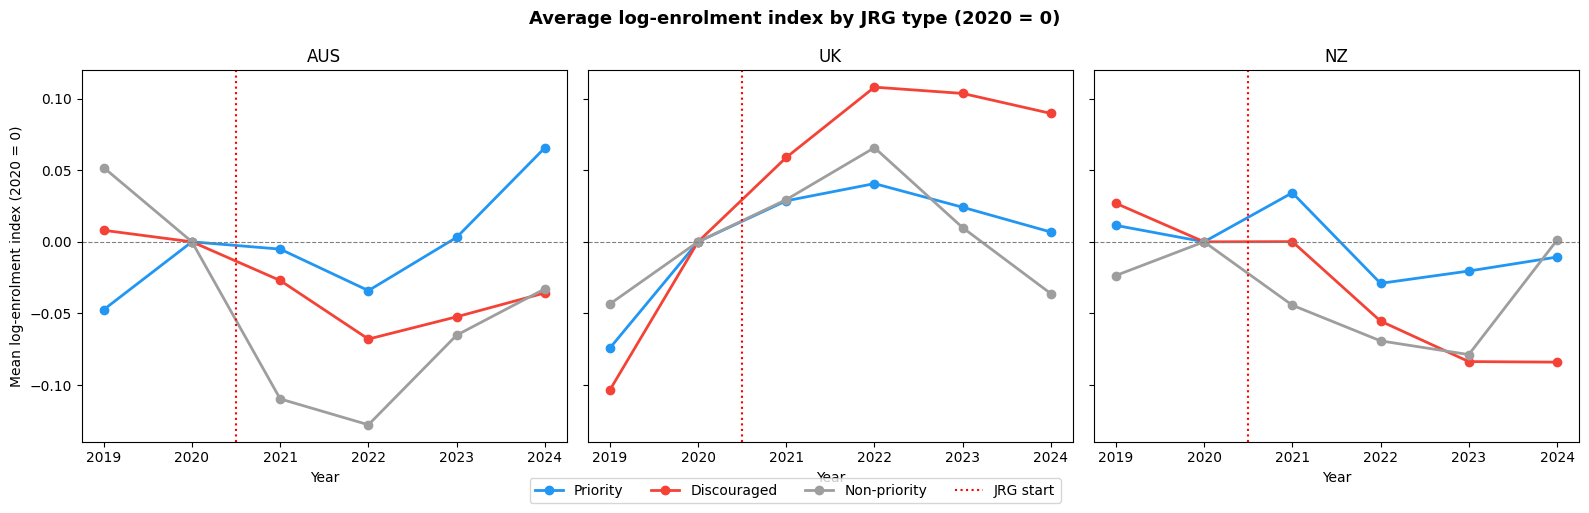


Post-2021 average index by country and JRG type:


jrg_type,Discouraged,Non-priority,Priority
country,,,
AUS,-0.0458,-0.0839,0.0074
NZ,-0.0557,-0.0478,-0.0064
UK,0.0901,0.0172,0.0251


In [3]:
# Index log-enrollments to 2020 = 0 within each discipline-country pair
base2020 = panel[panel['year'] == 2020].set_index(['disc_key', 'country'])['log_enrollments']
panel['log_idx'] = panel.apply(
    lambda r: r['log_enrollments'] - base2020.get((r['disc_key'], r['country']), np.nan), axis=1
)

# Average index by (country, jrg_type, year)
grp = panel.groupby(['country', 'jrg_type', 'year'])['log_idx'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Average log-enrolment index by JRG type (2020 = 0)', fontsize=13, fontweight='bold')

colours = {'Priority': '#2196F3', 'Discouraged': '#F44336', 'Non-priority': '#9E9E9E'}
country_order = ['AUS', 'UK', 'NZ']

for ax, country in zip(axes, country_order):
    for jtype, col in colours.items():
        sub = grp[(grp['country'] == country) & (grp['jrg_type'] == jtype)].sort_values('year')
        ax.plot(sub['year'], sub['log_idx'], 'o-', color=col, linewidth=2, label=jtype)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(2020.5, color='red', linestyle=':', linewidth=1.5, label='JRG start')
    ax.set_title(country, fontsize=12)
    ax.set_xlabel('Year')
    ax.set_xticks(sorted(panel['year'].unique()))

axes[0].set_ylabel('Mean log-enrolment index (2020 = 0)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

print('\nPost-2021 average index by country and JRG type:')
post_avg = panel[panel['post'] == 1].groupby(['country', 'jrg_type'])['log_idx'].mean().unstack()
display(post_avg.round(4))

## 3. Main DDD Regression

The full model includes:
- **Discipline fixed effects** `C(disc_key)` — absorb all time-invariant discipline-level differences
- **Country indicators** `treated`, `nz_dummy` — absorb country-level averages (UK is reference)
- **Year fixed effects** `C(year)` — absorb common time trends
- **`treated:post`** — the standard DiD: AUS average change post-2021 across all disciplines
- **`nz_dummy:post`** — NZ-specific post-2021 shift relative to UK
- **`priority:post`** — how priority disciplines changed on average across all three countries post-2021
- **`treated:priority`** and **`nz_dummy:priority`** — country-specific level differences for priority disciplines
- **`treated:post:priority`** — **the DDD coefficient**: the additional AUS post-2021 effect in priority
  disciplines relative to non-priority, beyond what UK and NZ show

Standard errors are HC3 robust throughout.

In [4]:
formula_ddd = """
log_enrollments ~
    C(disc_key) +
    treated + nz_dummy +
    C(year) +
    treated:post +
    nz_dummy:post +
    priority:post +
    treated:priority +
    nz_dummy:priority +
    treated:post:priority
"""

model_ddd = smf.ols(formula_ddd, data=panel).fit(cov_type='HC3')

# Extract key terms
key_terms = [
    'treated:post',
    'treated:post:priority',
    'priority:post',
    'nz_dummy:post',
]

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return ''

rows = []
for term in key_terms:
    if term not in model_ddd.params.index:
        continue
    b  = model_ddd.params[term]
    se = model_ddd.bse[term]
    pv = model_ddd.pvalues[term]
    ci = model_ddd.conf_int().loc[term]
    rows.append({
        'Term': term,
        'β': round(b, 4),
        'SE (HC3)': round(se, 4),
        'p-value': round(pv, 4),
        'Sig.': sig_stars(pv),
        '95% CI lo': round(ci[0], 4),
        '95% CI hi': round(ci[1], 4),
        'Approx. %': round((np.exp(b) - 1) * 100, 2),
    })

print('=== DDD Regression — Key Coefficients (HC3) ===')
print(f'N = {int(model_ddd.nobs)} | df = {int(model_ddd.df_resid)} | R² = {model_ddd.rsquared:.4f}')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10')
print()
display(pd.DataFrame(rows).set_index('Term'))

ddd_b  = model_ddd.params['treated:post:priority']
ddd_se = model_ddd.bse['treated:post:priority']
ddd_p  = model_ddd.pvalues['treated:post:priority']
ddd_ci = model_ddd.conf_int().loc['treated:post:priority']

print('\n--- DDD coefficient (treated:post:priority) ---')
print(f'  β = {ddd_b:.4f} | SE = {ddd_se:.4f} | p = {ddd_p:.4f} {sig_stars(ddd_p)}')
print(f'  95% CI: [{ddd_ci[0]:.4f}, {ddd_ci[1]:.4f}]')
print(f'  Approx. % effect: {(np.exp(ddd_b)-1)*100:+.1f}%')
print(f'\nInterpretation: post-JRG, priority disciplines in AUS grew')
print(f'approximately {(np.exp(ddd_b)-1)*100:+.1f}% more (or less) than non-priority disciplines')
print(f'in AUS, relative to the same within-country gap in UK and NZ.')

print('\n--- Full model summary ---')
print(model_ddd.summary())

=== DDD Regression — Key Coefficients (HC3) ===
N = 198 | df = 174 | R² = 0.9655
Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10



,β,SE (HC3),p-value,Sig.,95% CI lo,95% CI hi,Approx. %
Term,,,,,,,
treated:post,-0.1509,0.1481,0.3081,,-0.4412,0.1393,-14.01
treated:post:priority,0.1073,0.2050,0.6006,,-0.2944,0.5090,11.33
priority:post,0.0096,0.1158,0.9340,,-0.2174,0.2366,0.96
nz_dummy:post,-0.0994,0.1147,0.3860,,-0.3242,0.1254,-9.46



--- DDD coefficient (treated:post:priority) ---
  β = 0.1073 | SE = 0.2050 | p = 0.6006 
  95% CI: [-0.2944, 0.5090]
  Approx. % effect: +11.3%

Interpretation: post-JRG, priority disciplines in AUS grew
approximately +11.3% more (or less) than non-priority disciplines
in AUS, relative to the same within-country gap in UK and NZ.

--- Full model summary ---
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     308.3
Date:                Tue, 05 May 2026   Prob (F-statistic):          2.98e-128
Time:                        14:14:51   Log-Likelihood:                -25.264
No. Observations:                 198   AIC:                             98.53
Df Residuals:                     174   BIC:                             177.4
Df Mode

## 4. Year-by-Year Event Study

To check whether the DDD result is driven by post-2021 years and whether pre-2021 trends
were flat, we compute the DDD estimate year-by-year relative to the 2020 baseline:

$$\hat{\delta}_t = \underbrace{\bigl(\bar{Y}^{\text{AUS}}_{\text{pri},t} - \bar{Y}^{\text{AUS}}_{\text{npri},t}\bigr)}_{\text{AUS priority gap}} - \underbrace{\bigl(\bar{Y}^{\text{UK+NZ}}_{\text{pri},t} - \bar{Y}^{\text{UK+NZ}}_{\text{npri},t}\bigr)}_{\text{control priority gap}} - \text{(same difference in 2020)}$$

where $\bar{Y}$ is the mean log-enrolment index across disciplines within each group and year.
If the parallel trends assumption holds, pre-2021 estimates should be close to zero. Post-2021
estimates diverging from zero — particularly in the positive direction — would support the DDD story.

Event study: year-by-year DDD estimates (relative to 2020 baseline)


,AUS: priority vs non-priority (vs 2020),UK+NZ: priority vs non-priority (vs 2020),DDD_t,DDD_t approx. %,Period
Year,,,,,
2019,-0.0817,0.0040,-0.0858,-8.22,Pre
2020,0.0000,0.0000,0.0000,0.00,Baseline
2021,0.0716,0.0241,0.0475,4.86,Post
2022,0.0698,-0.0037,0.0735,7.62,Post
2023,0.0632,0.0185,0.0446,4.56,Post
2024,0.0997,0.0075,0.0922,9.66,Post


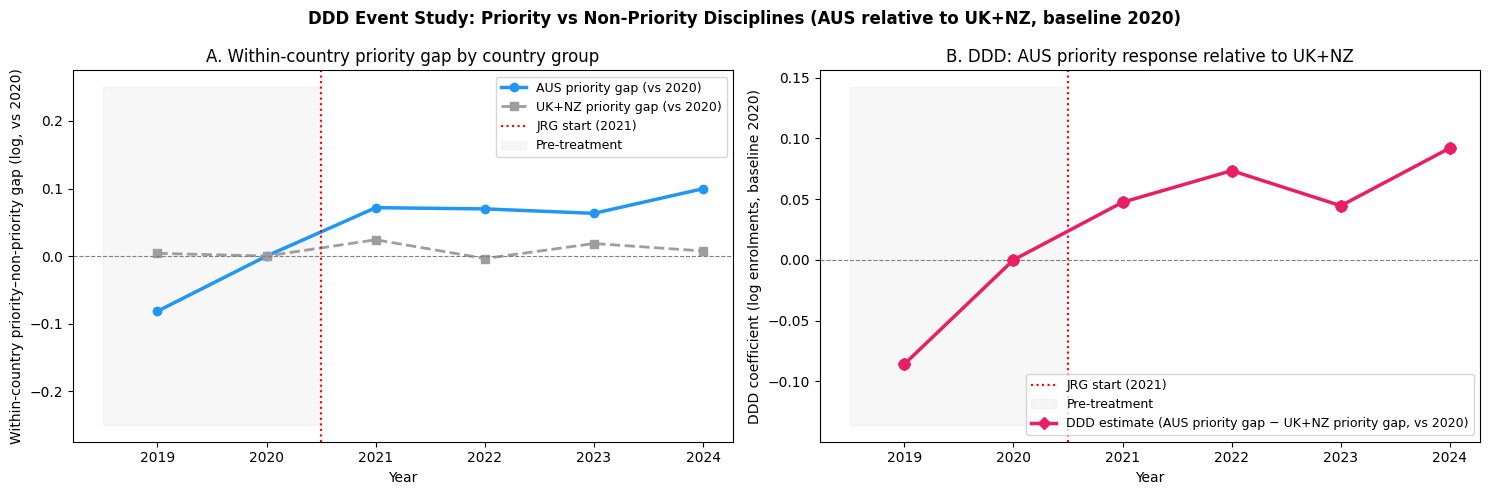

In [5]:
BASE_YEAR = 2020

def group_mean(country_list, pri_val, yr):
    mask = (
        panel['country'].isin(country_list) &
        (panel['priority'] == pri_val) &
        (panel['year'] == yr)
    )
    return panel.loc[mask, 'log_enrollments'].mean()

aus_list  = ['AUS']
ctrl_list = ['UK', 'NZ']

# Baseline values (2020)
b_aus_pri  = group_mean(aus_list,  1, BASE_YEAR)
b_aus_npri = group_mean(aus_list,  0, BASE_YEAR)
b_ctl_pri  = group_mean(ctrl_list, 1, BASE_YEAR)
b_ctl_npri = group_mean(ctrl_list, 0, BASE_YEAR)

es_rows = []
for yr in sorted(panel['year'].unique()):
    aus_pri  = group_mean(aus_list,  1, yr)
    aus_npri = group_mean(aus_list,  0, yr)
    ctl_pri  = group_mean(ctrl_list, 1, yr)
    ctl_npri = group_mean(ctrl_list, 0, yr)

    did_aus_t = (aus_pri  - aus_npri)  - (b_aus_pri  - b_aus_npri)
    did_ctl_t = (ctl_pri  - ctl_npri)  - (b_ctl_pri  - b_ctl_npri)
    ddd_t     = did_aus_t - did_ctl_t

    es_rows.append({
        'Year': yr,
        'AUS: priority vs non-priority (vs 2020)': round(did_aus_t, 4),
        'UK+NZ: priority vs non-priority (vs 2020)': round(did_ctl_t, 4),
        'DDD_t': round(ddd_t, 4),
        'DDD_t approx. %': round((np.exp(ddd_t) - 1) * 100, 2),
        'Period': 'Baseline' if yr == BASE_YEAR else ('Pre' if yr < 2021 else 'Post'),
    })

es = pd.DataFrame(es_rows).set_index('Year')
print('Event study: year-by-year DDD estimates (relative to 2020 baseline)')
display(es)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('DDD Event Study: Priority vs Non-Priority Disciplines (AUS relative to UK+NZ, baseline 2020)',
             fontsize=12, fontweight='bold')

years_plot = sorted(panel['year'].unique())

# Panel A: within-country priority gaps
did_aus_vals = es['AUS: priority vs non-priority (vs 2020)'].values
did_ctl_vals = es['UK+NZ: priority vs non-priority (vs 2020)'].values

axes[0].plot(years_plot, did_aus_vals, 'o-', color='#2196F3', linewidth=2.5, label='AUS priority gap (vs 2020)')
axes[0].plot(years_plot, did_ctl_vals, 's--', color='#9E9E9E', linewidth=2, label='UK+NZ priority gap (vs 2020)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(2020.5, color='red', linestyle=':', linewidth=1.5, label='JRG start (2021)')
axes[0].fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Within-country priority–non-priority gap (log, vs 2020)')
axes[0].set_title('A. Within-country priority gap by country group')
axes[0].set_xticks(years_plot); axes[0].legend(fontsize=9)

# Panel B: DDD
ddd_vals = es['DDD_t'].values
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(2020.5, color='red', linestyle=':', linewidth=1.5, label='JRG start (2021)')
axes[1].fill_between([2018.5, 2020.5], min(ddd_vals) - 0.05, max(ddd_vals) + 0.05,
                     color='gray', alpha=0.06, label='Pre-treatment')
axes[1].plot(years_plot, ddd_vals, 'D-', color='#E91E63', linewidth=2.5,
             label='DDD estimate (AUS priority gap − UK+NZ priority gap, vs 2020)')
axes[1].scatter(years_plot, ddd_vals, color='#E91E63', s=60, zorder=5)
axes[1].set_xlabel('Year'); axes[1].set_ylabel('DDD coefficient (log enrolments, baseline 2020)')
axes[1].set_title('B. DDD: AUS priority response relative to UK+NZ')
axes[1].set_xticks(years_plot); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Robustness Checks

Three alternative specifications:

1. **Priority vs Discouraged only** — restricts the sample to priority (6) and discouraged (2)
   disciplines, dropping the neutral non-priority group. This is the sharpest policy contrast.

2. **Full-panel disciplines only (2016–2024)** — uses only the 7 disciplines with consistent
   UK data from 2016: IT, Engineering, Architecture, Health, Education, M&C, Creative Arts.
   Longer pre-period at the cost of excluding 4 disciplines.

3. **Separate `priority` and `discouraged` DDD terms** — estimates both the priority
   differential (`treated:post:priority`) and the discouraged differential
   (`treated:post:discouraged`) simultaneously, with the neutral non-priority group as the
   reference. This tests whether discouraged fields fell relative to neutral as well.

In [6]:
# ── Spec 1: Priority vs Discouraged only ─────────────────────────────────────
p_pri_disc = panel[panel['jrg_type'].isin(['Priority', 'Discouraged'])].copy()
m1 = smf.ols(formula_ddd, data=p_pri_disc).fit(cov_type='HC3')
b1 = m1.params.get('treated:post:priority', np.nan)
p1 = m1.pvalues.get('treated:post:priority', np.nan)
se1 = m1.bse.get('treated:post:priority', np.nan)
print(f'Spec 1 — Priority vs Discouraged only (N={int(m1.nobs)}, df={int(m1.df_resid)}):')
print(f'  DDD β = {b1:.4f} | SE = {se1:.4f} | p = {p1:.4f} {sig_stars(p1)} | ≈ {(np.exp(b1)-1)*100:+.1f}%')

# ── Spec 2: Full-panel disciplines (2016–2024) ────────────────────────────────
FULL_PANEL_KEYS = [2, 3, 4, 6, 7, 8, 10]  # IT, Eng, Arch, Health, Edu, M&C, Creative Arts
frames2 = []
for catkey in FULL_PANEL_KEYS:
    name, jrg_type = DISC_CONFIG[catkey]
    aus_f = aus_long[
        (aus_long['CategoryKey'] == catkey) &
        (aus_long['year'] >= 2016) &
        (aus_long['year'] <= END_YEAR)
    ][['year', 'enrollments']].copy()
    aus_f['country'] = 'AUS'

    uk_f = uk_raw[uk_raw['categorykey'] == catkey].copy()
    uk_f['year'] = uk_f['AcademicYear'].str[:4].astype(int)
    uk_f = uk_f[(uk_f['year'] >= 2016) & (uk_f['year'] <= END_YEAR)].copy()
    uk_f['enrollments'] = pd.to_numeric(uk_f['Total UK'], errors='coerce')
    uk_f = uk_f.groupby('year', as_index=False)['enrollments'].sum()
    uk_f['country'] = 'UK'

    nz_f = nz_raw[nz_raw['category_key'] == catkey][['year', 'total_bachelors']].copy()
    nz_f = nz_f.rename(columns={'total_bachelors': 'enrollments'})
    nz_f['country'] = 'NZ'
    nz_f = nz_f[(nz_f['year'] >= 2016) & (nz_f['year'] <= END_YEAR)].copy()

    for df_f in [aus_f, uk_f, nz_f]:
        df_f['disc_key']  = catkey
        df_f['disc_name'] = name
        df_f['jrg_type']  = jrg_type
    frames2.append(pd.concat([aus_f, uk_f, nz_f], ignore_index=True))

panel2 = pd.concat(frames2, ignore_index=True).reset_index(drop=True)
panel2['log_enrollments'] = np.log(panel2['enrollments'])
panel2['treated']     = (panel2['country'] == 'AUS').astype(int)
panel2['nz_dummy']    = (panel2['country'] == 'NZ').astype(int)
panel2['post']        = (panel2['year'] >= 2021).astype(int)
panel2['priority']    = panel2['jrg_type'].eq('Priority').astype(int)
panel2['discouraged'] = panel2['jrg_type'].eq('Discouraged').astype(int)

m2 = smf.ols(formula_ddd, data=panel2).fit(cov_type='HC3')
b2 = m2.params.get('treated:post:priority', np.nan)
p2 = m2.pvalues.get('treated:post:priority', np.nan)
se2 = m2.bse.get('treated:post:priority', np.nan)
print(f'\nSpec 2 — Full-panel disciplines only, 2016–2024 (N={int(m2.nobs)}, df={int(m2.df_resid)}):')
print(f'  DDD β = {b2:.4f} | SE = {se2:.4f} | p = {p2:.4f} {sig_stars(p2)} | ≈ {(np.exp(b2)-1)*100:+.1f}%')

# ── Spec 3: Separate priority and discouraged DDD terms ───────────────────────
formula_split = """
log_enrollments ~
    C(disc_key) +
    treated + nz_dummy +
    C(year) +
    treated:post +
    nz_dummy:post +
    priority:post +
    discouraged:post +
    treated:priority +
    treated:discouraged +
    nz_dummy:priority +
    nz_dummy:discouraged +
    treated:post:priority +
    treated:post:discouraged
"""
m3 = smf.ols(formula_split, data=panel).fit(cov_type='HC3')
b3p  = m3.params.get('treated:post:priority',    np.nan)
p3p  = m3.pvalues.get('treated:post:priority',   np.nan)
se3p = m3.bse.get('treated:post:priority',       np.nan)
b3d  = m3.params.get('treated:post:discouraged', np.nan)
p3d  = m3.pvalues.get('treated:post:discouraged',np.nan)
se3d = m3.bse.get('treated:post:discouraged',    np.nan)
print(f'\nSpec 3 — Separate priority and discouraged DDD (N={int(m3.nobs)}, df={int(m3.df_resid)}):')
print(f'  Priority DDD:    β = {b3p:.4f} | SE = {se3p:.4f} | p = {p3p:.4f} {sig_stars(p3p)} | ≈ {(np.exp(b3p)-1)*100:+.1f}%')
print(f'  Discouraged DDD: β = {b3d:.4f} | SE = {se3d:.4f} | p = {p3d:.4f} {sig_stars(p3d)} | ≈ {(np.exp(b3d)-1)*100:+.1f}%')

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n=== Robustness Summary ===')
rob_rows = [
    {'Specification': 'Main (all 11 disciplines, 2019–2024)',
     'N': int(model_ddd.nobs), 'df': int(model_ddd.df_resid),
     'DDD β (priority)': round(ddd_b, 4), 'SE': round(ddd_se, 4), 'p': round(ddd_p, 4),
     'Sig.': sig_stars(ddd_p), 'Approx. %': round((np.exp(ddd_b)-1)*100, 1)},
    {'Specification': 'Priority vs Discouraged only',
     'N': int(m1.nobs), 'df': int(m1.df_resid),
     'DDD β (priority)': round(b1, 4), 'SE': round(se1, 4), 'p': round(p1, 4),
     'Sig.': sig_stars(p1), 'Approx. %': round((np.exp(b1)-1)*100, 1)},
    {'Specification': 'Full-panel disciplines only (2016–2024)',
     'N': int(m2.nobs), 'df': int(m2.df_resid),
     'DDD β (priority)': round(b2, 4), 'SE': round(se2, 4), 'p': round(p2, 4),
     'Sig.': sig_stars(p2), 'Approx. %': round((np.exp(b2)-1)*100, 1)},
    {'Specification': 'Split DDD — priority term (non-priority reference)',
     'N': int(m3.nobs), 'df': int(m3.df_resid),
     'DDD β (priority)': round(b3p, 4), 'SE': round(se3p, 4), 'p': round(p3p, 4),
     'Sig.': sig_stars(p3p), 'Approx. %': round((np.exp(b3p)-1)*100, 1)},
    {'Specification': 'Split DDD — discouraged term (non-priority reference)',
     'N': int(m3.nobs), 'df': int(m3.df_resid),
     'DDD β (priority)': round(b3d, 4), 'SE': round(se3d, 4), 'p': round(p3d, 4),
     'Sig.': sig_stars(p3d), 'Approx. %': round((np.exp(b3d)-1)*100, 1)},
]
display(pd.DataFrame(rob_rows).set_index('Specification'))

Spec 1 — Priority vs Discouraged only (N=144, df=123):
  DDD β = 0.0922 | SE = 0.2315 | p = 0.6905  | ≈ +9.7%

Spec 2 — Full-panel disciplines only, 2016–2024 (N=189, df=166):
  DDD β = 0.1699 | SE = 0.1433 | p = 0.2356  | ≈ +18.5%

Spec 3 — Separate priority and discouraged DDD (N=198, df=170):
  Priority DDD:    β = 0.1174 | SE = 0.2648 | p = 0.6575  | ≈ +12.5%
  Discouraged DDD: β = 0.0252 | SE = 0.2912 | p = 0.9311  | ≈ +2.5%

=== Robustness Summary ===


,N,df,DDD β (priority),SE,p,Sig.,Approx. %
Specification,,,,,,,
"Main (all 11 disciplines, 2019–2024)",198,174,0.1073,0.2050,0.6006,,11.3
Priority vs Discouraged only,144,123,0.0922,0.2315,0.6905,,9.7
Full-panel disciplines only (2016–2024),189,166,0.1699,0.1433,0.2356,,18.5
Split DDD — priority term (non-priority reference),198,170,0.1174,0.2648,0.6575,,12.5
Split DDD — discouraged term (non-priority reference),198,170,0.0252,0.2912,0.9311,,2.5


## 6. Summary

### What the DDD estimates

The DDD coefficient (`treated:post:priority`) answers a specific question: **did the mix of
enrolments shift toward priority disciplines in Australia more than in the UK and NZ after 2021?**
This is a within-country, cross-discipline comparison stacked on top of a cross-country comparison,
and it is identified from the 198-observation pooled panel rather than from a single discipline.

### Interpreting the result

| Result | Interpretation |
|--------|----------------|
| DDD β > 0, significant | Priority disciplines grew relative to non-priority in AUS, beyond what UK/NZ show — consistent with JRG fee incentives working |
| DDD β < 0, significant | Priority disciplines *underperformed* non-priority in AUS relative to UK/NZ — contrary to policy intent |
| DDD β ≈ 0, not significant | No detectable relative shift in enrolment mix by discipline type — JRG did not measurably redirect students toward priority fields |

### Statistical note

With N = 198 and df ≈ 174, the DDD has far more power than any individual discipline regression
(where df = 4–15). This means a null result here is more informative — if the DDD coefficient
is small and insignificant, it is unlikely to be driven by insufficient power alone.

### Caveats

- The DDD assumes that, in the absence of JRG, the priority–non-priority enrolment gap within
  Australia would have evolved similarly to the same gap in the UK and NZ. If priority disciplines
  in Australia were already trending differently for structural reasons (e.g., workforce shortages
  in nursing and teaching driving AUS-specific demand in Health and Education), the DDD estimate
  would absorb those trends.
- The single pre-treatment year (2019) for five disciplines limits the ability to formally test
  this assumption. The event study pre-period estimates provide a partial check.
- The 'Others' and 'Environment' categories carry specific data quality warnings noted in their
  individual REG notebooks; their inclusion in the pooled panel may introduce noise.